# Consumer Tier Classification

In [1]:
import pandas as pd
retail_df=pd.read_csv('../data/processed/retail_cleaned.csv')

In [2]:
customer_sales=(

retail_df.groupby(

'Customer ID'

)['Sales']

.sum()

.reset_index()

)

In [3]:
customer_sales.head()

,Customer ID,Sales
0,CUST000001,3344.69
1,CUST000002,37094.41
2,CUST000003,35501.08
3,CUST000004,8969.33
4,CUST000005,35530.44


In [4]:
high=customer_sales['Sales'].quantile(.80)

In [5]:
medium=customer_sales['Sales'].quantile(.40)

In [6]:
def classify(x):


    if x>=high:

        return 'High Value'


    elif x>=medium:

        return 'Medium Value'


    return 'Low Value'

In [7]:
customer_sales['Customer Segment']=customer_sales['Sales'].apply(classify)

In [8]:
customer_sales.head()

,Customer ID,Sales,Customer Segment
0,CUST000001,3344.69,Low Value
1,CUST000002,37094.41,Medium Value
2,CUST000003,35501.08,Medium Value
3,CUST000004,8969.33,Low Value
4,CUST000005,35530.44,Medium Value


<Axes: xlabel='Customer Segment', ylabel='count'>

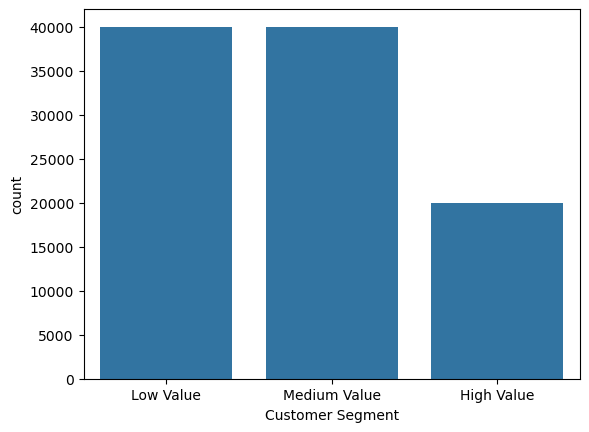

In [10]:
import seaborn as sns

sns.countplot(
    data=customer_sales,
    x='Customer Segment'
)


In [11]:
customer_sales.to_csv(

'../outputs/customer_segments.csv',

index=False
)

In [12]:
retail_df=retail_df.merge(

customer_sales,

on='Customer ID'
)

In [13]:
retail_df.to_csv(

'../data/processed/retail_cleaned.csv',

index=False
)